# Multi-Model AutoML LOOCV Pipeline (Paired 비교)

각 모델을 **두 데이터셋에 동일하게** 적용해 1:1로 비교합니다.
- **Clinical_ONLY**: `vas_t0`, `treatment_group` (2개)
- **Brain_Plus_Clinical**: 위 2개 + Morphometric ROI 10개 (Residualized)
- **제거 변수**: age, sex, eTIV / **타겟**: vas_t1

이전 버전은 Baseline만 튜닝 없이 돌려서, 성능 차이가 뇌 지표 때문인지
튜닝 때문인지 구분되지 않았습니다. 이제 두 데이터셋 모두 같은 모델·같은 GridSearchCV를 거칩니다.

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION
# ==========================================================
df = pd.read_csv('structural_full_68_68_16_edited.csv', skipinitialspace=True)
df.columns = df.columns.str.strip()

# 10개 ROI 특징
morph_features = [
    'lh_rostralmiddlefrontal_thick', 'rh_rostralmiddlefrontal_thick',
    'lh_Caudate_vol', 'rh_Caudate_vol',
    'lh_Putamen_vol', 'rh_Putamen_vol',
    'lh_Accumbens_vol', 'rh_Accumbens_vol',
    'lh_lateralorbitofrontal_thick', 'lh_rostralanteriorcingulate_thick'
]

nuisance_covariates = ['age', 'sex', 'eTIV']
clinical_predictors = ['vas_t0', 'treatment_group']
target = 'vas_t1'

X_morph = df[morph_features].values
X_nuisance = df[nuisance_covariates].values
X_clinical = df[clinical_predictors].values
y = df[target].values

In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP
# ==========================================================
# [변경] Baseline 항목 삭제. 모든 모델이 두 데이터셋에 동일하게 적용됨.
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],   # 위로 확장
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]    # 아래로 확장
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]                # 위로
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로 (최우선)
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],        # 아래로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]                        # split보다 leaf가 n작을 때 효과적
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],                                 # n=45면 5는 과함
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]                                # 규제 추가
    },
}

DATA_TYPES = ['Clinical_ONLY', 'Brain_Plus_Clinical']

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
# ==========================================================
loo = LeaveOneOut()
# [변경] 예측을 (데이터셋, 모델) 조합별로 저장
predictions = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_morph)):
    print(f"Processing fold {fold_idx+1}/{len(y)}...", end='\r')

    X_m_train, X_m_test = X_morph[train_idx], X_morph[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- Nuisance Residualization ---
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_m_train)
    X_m_train_clean = X_m_train - nuisance_regressor.predict(X_n_train)
    X_m_test_clean = X_m_test - nuisance_regressor.predict(X_n_test)

    # --- Features Stack ---
    X_train_full = np.hstack([X_m_train_clean, X_c_train])
    X_test_full = np.hstack([X_m_test_clean, X_c_test])

    y_true.append(y_test[0])

    # [변경] 두 데이터셋을 딕셔너리로 묶어 동일하게 처리
    raw_sets = {
        'Clinical_ONLY': (X_c_train, X_c_test),
        'Brain_Plus_Clinical': (X_train_full, X_test_full),
    }

    for dt, (X_tr_raw, X_te_raw) in raw_sets.items():
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr_raw)
        X_te = scaler.transform(X_te_raw)

        for name, model in models.items():
            inner_cv = GridSearchCV(model, param_grids[name], cv=3,
                                    scoring='neg_mean_squared_error', n_jobs=-1)
            inner_cv.fit(X_tr, y_train)
            pred = inner_cv.best_estimator_.predict(X_te)
            predictions[(dt, name)].append(pred[0])
            best_params_log[(dt, name)].append(str(inner_cv.best_params_))

print("\n\nLOOCV Completed.")

Starting LOOCV: 6 models x 2 datasets...

Processing fold 45/45...

LOOCV Completed.


In [5]:
# ==========================================================
# 4. EVALUATION & PAIRED COMPARISON
# ==========================================================
y_true = np.array(y_true)

results = []
for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)
    corr, p_val = pearsonr(y_true, y_pred)
    results.append({
        'Data Type': dt,
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2 Score': r2_score(y_true, y_pred),
        'Pearson (r)': corr,
        'p-value': p_val,
    })

results_df = pd.DataFrame(results)

# --- 기준선: 평균만 예측하는 모델 ---
baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델의 LOOCV RMSE = {baseline_rmse:.3f}")
print("  -> 이 값보다 나쁜 모델은 예측력이 없는 것임\n")

# --- Paired 표 (행 = 모델, 열 = 데이터셋) ---
pivot = results_df.pivot(index='Model', columns='Data Type', values='RMSE')
pivot['dRMSE'] = pivot['Clinical_ONLY'] - pivot['Brain_Plus_Clinical']
pivot = pivot.sort_index()   # dRMSE 정렬 안 함 (좋은 것만 골라 읽게 되므로)

n_pos = int((pivot['dRMSE'] > 0).sum())
n_tot = len(pivot)

print("========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========")
display(pivot)

print(f"\n부호 일관성: {n_tot}개 중 {n_pos}개가 +")
if n_pos == n_tot:
    print("  -> 전부 +. 알고리즘 선택과 무관하게 개선.")
elif n_pos == 0:
    print("  -> 전부 -. 뇌 지표가 오히려 해가 됨.")
else:
    print("  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.")
    print("  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== 전체 지표 ==========")
display(results_df.sort_values(['Model', 'Data Type']))

평균만 예측하는 모델의 LOOCV RMSE = 2.436
  -> 이 값보다 나쁜 모델은 예측력이 없는 것임

========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========


Data Type,Brain_Plus_Clinical,Clinical_ONLY,dRMSE
Model,,,
ElasticNet,2.281366,2.172883,-0.108482
LinearRegression,2.525538,2.175121,-0.350416
RandomForest,2.411754,2.469457,0.057703
SVR_Linear,2.299349,2.165318,-0.134031
SVR_RBF,2.301972,2.422185,0.120213
XGBoost,2.289015,2.419757,0.130742



부호 일관성: 6개 중 3개가 +
  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.
  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.

========== 전체 지표 ==========


,Data Type,Model,RMSE,R2 Score,Pearson (r),p-value
7,Brain_Plus_Clinical,ElasticNet,2.281366,0.082736,0.310348,0.038002
1,Clinical_ONLY,ElasticNet,2.172883,0.167896,0.423841,0.003716
6,Brain_Plus_Clinical,LinearRegression,2.525538,-0.124119,0.328826,0.027420
0,Clinical_ONLY,LinearRegression,2.175121,0.166181,0.424659,0.003643
10,Brain_Plus_Clinical,RandomForest,2.411754,-0.025111,0.197014,0.194571
4,Clinical_ONLY,RandomForest,2.469457,-0.074751,0.225351,0.136650
8,Brain_Plus_Clinical,SVR_Linear,2.299349,0.068217,0.383158,0.009378
2,Clinical_ONLY,SVR_Linear,2.165318,0.173680,0.439379,0.002530
9,Brain_Plus_Clinical,SVR_RBF,2.301972,0.066091,0.318846,0.032780
3,Clinical_ONLY,SVR_RBF,2.422185,-0.033997,0.263854,0.079883


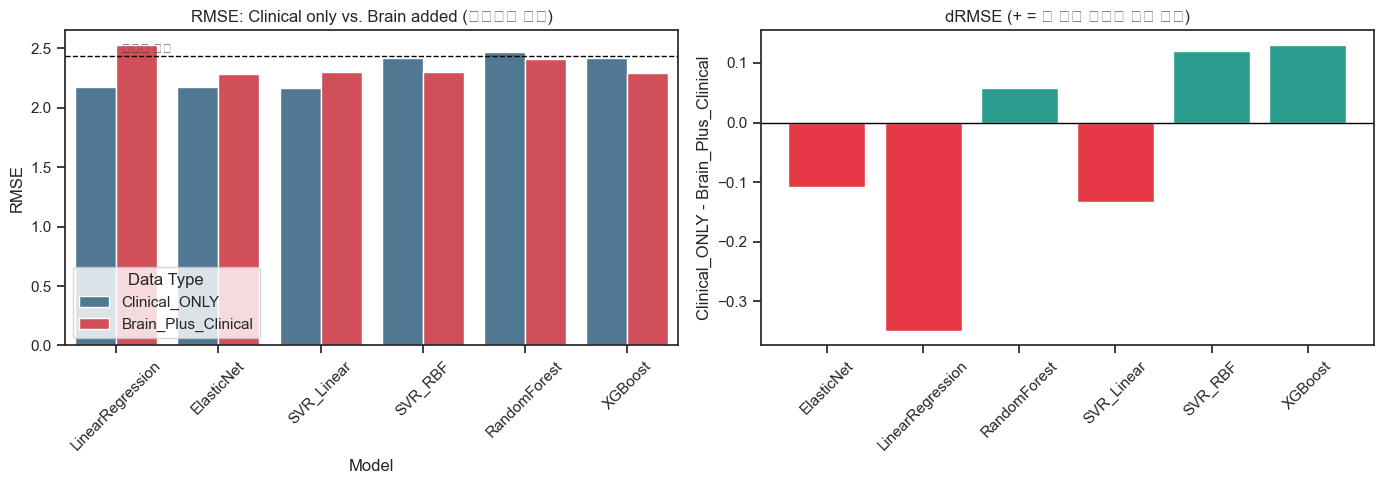

In [6]:
# ==========================================================
# 5. VISUALIZATION (Paired)
# ==========================================================
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 모델별 RMSE를 데이터셋으로 나눠 나란히
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Data Type',
            palette=['#457B9D', '#E63946'], ax=axes[0])
axes[0].axhline(baseline_rmse, color='black', linestyle='--', linewidth=1)
axes[0].text(0.02, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
axes[0].set_title('RMSE: Clinical only vs. Brain added (낮을수록 좋음)')
axes[0].tick_params(axis='x', rotation=45)

# 오른쪽: dRMSE
colors = ['#2A9D8F' if v > 0 else '#E63946' for v in pivot['dRMSE']]
axes[1].bar(pivot.index, pivot['dRMSE'], color=colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('dRMSE (+ = 뇌 지표 추가로 오차 감소)')
axes[1].set_ylabel('Clinical_ONLY - Brain_Plus_Clinical')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# ==========================================================
# 6. 하이퍼파라미터 안정성 (선택 사항)
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{name} / {dt}] 고유 조합 {len(vc)}개, 최빈 {share:.0%}{flag}")

[LinearRegression / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[ElasticNet / Clinical_ONLY] 고유 조합 2개, 최빈 96%
[SVR_Linear / Clinical_ONLY] 고유 조합 11개, 최빈 33%   <-- 불안정
[SVR_RBF / Clinical_ONLY] 고유 조합 8개, 최빈 78%
[RandomForest / Clinical_ONLY] 고유 조합 6개, 최빈 67%
[XGBoost / Clinical_ONLY] 고유 조합 5개, 최빈 80%
[LinearRegression / Brain_Plus_Clinical] 고유 조합 1개, 최빈 100%
[ElasticNet / Brain_Plus_Clinical] 고유 조합 5개, 최빈 51%
[SVR_Linear / Brain_Plus_Clinical] 고유 조합 5개, 최빈 87%
[SVR_RBF / Brain_Plus_Clinical] 고유 조합 8개, 최빈 49%   <-- 불안정
[RandomForest / Brain_Plus_Clinical] 고유 조합 9개, 최빈 31%   <-- 불안정
[XGBoost / Brain_Plus_Clinical] 고유 조합 9개, 최빈 40%   <-- 불안정
